# Project 20 — CAPSTONE: Primate Milk Energy (multivariate + missing-data imputation + LOO + SBC)

**Tier 4 · Capstone** | **Author:** Truong Van Thien, PhD (TS. Trương Văn Thiên) | **Date:** 12-06-2026 | **Model tag:** Opus48

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tvthienbk/biofx_python/blob/main/bayesian-workflow-20/P20_capstone-milk/P20_capstone-milk_12-06-2026_Opus48.ipynb)

The capstone integrates the whole workflow: a **multivariate** regression of milk energy on body mass and
neocortex size, with **Bayesian missing-data imputation** (12 of 29 neocortex values are missing),
**PSIS-LOO model selection**, **power-scaling sensitivity**, and **Simulation-Based Calibration**. It also
showcases a **masking/suppression** effect: two predictors that each look weak alone become strong together.

## Learning objectives
1. Impute missing predictor values **inside** the model (not by dropping rows or mean-filling).
2. Reveal a **masked association**: mass and neocortex jointly explain milk energy though neither does alone.
3. Select among nested models with **PSIS-LOO** read against its SE; assess **power-scaling** sensitivity.
4. Validate the model end-to-end with **SBC**.

## Setup

In [1]:
# !pip install -q "pymc>=5.16" "arviz>=0.18" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7"
import os, io, time, urllib.request, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
import scipy.stats as st
warnings.simplefilter("ignore"); az.style.use("arviz-darkgrid")
RANDOM_SEED = 20
rng = np.random.default_rng(RANDOM_SEED)
print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 5.28.5 | arviz 0.23.4


## Stage 0 — Fake-data parameter recovery [required]
Simulate complete `K = a + bN·N + bM·M + noise` with known coefficients, fit the complete-case model,
confirm recovery — before adding imputation on real data.

In [2]:
a_t, bN_t, bM_t, s_t = 0.0, 0.6, -0.6, 0.4
M_s = rng.normal(0,1,40); N_s = rng.normal(0,1,40)
K_s = rng.normal(a_t + bN_t*N_s + bM_t*M_s, s_t)
with pm.Model() as m0:
    a=pm.Normal("a",0,0.5); bN=pm.Normal("bN",0,0.5); bM=pm.Normal("bM",0,0.5); sigma=pm.Exponential("sigma",1)
    pm.Normal("K", a+bN*N_s+bM*M_s, sigma, observed=K_s)
    idata0=pm.sample(1000,tune=1000,chains=4,target_accept=0.9,random_seed=RANDOM_SEED,progressbar=False)
s0=az.summary(idata0,hdi_prob=0.9)
print(s0[["mean","hdi_5%","hdi_95%","r_hat"]])
for nm,tr in [("a",a_t),("bN",bN_t),("bM",bM_t),("sigma",s_t)]:
    print(nm,"recovered:", s0.loc[nm,"hdi_5%"]<=tr<=s0.loc[nm,"hdi_95%"])

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, bN, bM, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


        mean  hdi_5%  hdi_95%  r_hat
a     -0.041  -0.173    0.085    1.0
bN     0.713   0.596    0.828    1.0
bM    -0.675  -0.800   -0.560    1.0
sigma  0.478   0.392    0.574    1.0
a recovered: True
bN recovered: True
bM recovered: True
sigma recovered: True


## Data load — milk (`;`-delimited)

In [3]:
URL = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/milk.csv"
CACHE = "data/milk.csv"
try:
    raw = urllib.request.urlopen(URL, timeout=30).read().decode()
    os.makedirs("data", exist_ok=True); open(CACHE, "w").write(raw)
    df = pd.read_csv(io.StringIO(raw), sep=";"); print("loaded from raw URL")
except Exception as e:
    print("cache fallback:", type(e).__name__); df = pd.read_csv(CACHE, sep=";")
print("shape:", df.shape, "| neocortex missing:", int(df["neocortex.perc"].isna().sum()))
df.head()

loaded from raw URL
shape: (29, 8) | neocortex missing: 12


,clade,species,kcal.per.g,perc.fat,perc.protein,perc.lactose,mass,neocortex.perc
0,Strepsirrhine,Eulemur fulvus,0.49,16.60,15.42,67.98,1.95,55.16
1,Strepsirrhine,E macaco,0.51,19.27,16.91,63.82,2.09,NaN
2,Strepsirrhine,E mongoz,0.46,14.11,16.85,69.04,2.51,NaN
3,Strepsirrhine,E rubriventer,0.48,14.91,13.18,71.91,1.62,NaN
4,Strepsirrhine,Lemur catta,0.60,27.28,19.50,53.22,2.19,NaN


## Stage 1–2 — Question & EDA
**Question:** does milk energy density (`kcal.per.g`) increase with relative brain size
(`neocortex.perc`) once body mass is accounted for? **Unit:** one primate species (n=29). Standardize all
variables; **mass enters as log(mass)**. 12 neocortex values are missing — the modelling challenge.

n=29 | observed neocortex: 17 | missing: 12


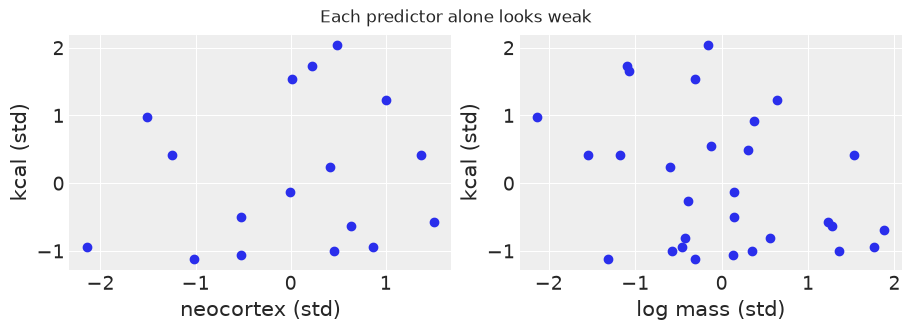

In [4]:
K = ((df["kcal.per.g"] - df["kcal.per.g"].mean())/df["kcal.per.g"].std()).values
logmass = np.log(df["mass"].values)
M = ((logmass - logmass.mean())/logmass.std())
neo = df["neocortex.perc"].values
neo_mean, neo_sd = np.nanmean(neo), np.nanstd(neo)
N = (neo - neo_mean)/neo_sd                 # contains np.nan where missing
print(f"n={len(K)} | observed neocortex: {np.sum(~np.isnan(N))} | missing: {np.sum(np.isnan(N))}")
fig,ax=plt.subplots(1,2,figsize=(9,3.2))
ax[0].scatter(N, K); ax[0].set_xlabel("neocortex (std)"); ax[0].set_ylabel("kcal (std)")
ax[1].scatter(M, K); ax[1].set_xlabel("log mass (std)"); ax[1].set_ylabel("kcal (std)")
plt.suptitle("Each predictor alone looks weak"); plt.show()

## Stage 3 — Full model with missing-data imputation
Missing neocortex values are treated as **parameters with a prior**, estimated jointly with everything
else (Bayesian imputation). PyMC auto-imputes when `observed` contains NaN: it splits `N` into observed
and unobserved (latent) entries.
$$K_i\sim\mathrm{Normal}(a+b_N N_i+b_M M_i,\sigma),\quad N_i\sim\mathrm{Normal}(\nu,\sigma_N),$$
priors `a,bN,bM~Normal(0,0.5)`, `sigma,sigma_N~Exponential(1)`, `nu~Normal(0,1)`.

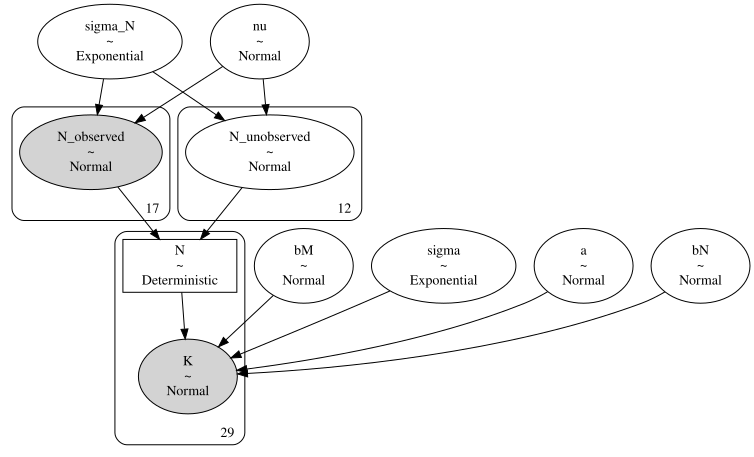

In [5]:
N_masked = np.ma.masked_invalid(N)
with pm.Model() as model_full:
    nu = pm.Normal("nu", 0, 1); sigma_N = pm.Exponential("sigma_N", 1)
    N_impute = pm.Normal("N", nu, sigma_N, observed=N_masked)   # auto-imputes missing entries
    a = pm.Normal("a", 0, 0.5); bN = pm.Normal("bN", 0, 0.5); bM = pm.Normal("bM", 0, 0.5)
    sigma = pm.Exponential("sigma", 1)
    mu = a + bN*N_impute + bM*M
    K_obs = pm.Normal("K", mu, sigma, observed=K)
try:
    display(pm.model_to_graphviz(model_full))
except Exception as ex:
    print("graphviz unavailable:", type(ex).__name__)

## Stage 4 — Prior predictive (outcome = standardized kcal)

Sampling: [K, N_observed, N_unobserved, a, bM, bN, nu, sigma, sigma_N]


prior-predictive K (std units): 5-95% = [-2.5, 2.7] (data are ~[-2,2])


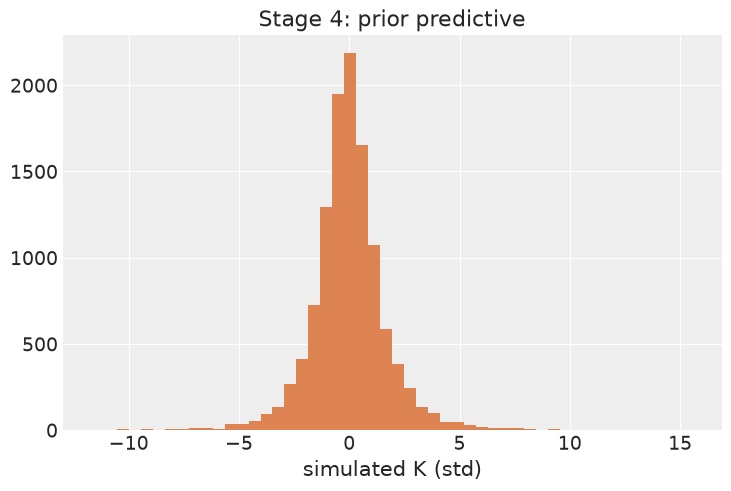

In [6]:
with model_full:
    prior = pm.sample_prior_predictive(samples=400, random_seed=RANDOM_SEED)
pp = prior.prior_predictive["K"].values.reshape(-1)
print(f"prior-predictive K (std units): 5-95% = [{np.percentile(pp,5):.1f}, {np.percentile(pp,95):.1f}] (data are ~[-2,2])")
plt.hist(pp, bins=50, color="#dd8452"); plt.xlabel("simulated K (std)"); plt.title("Stage 4: prior predictive"); plt.show()

## Stage 5 — Fit

In [7]:
t0=time.time()
with model_full:
    idata = pm.sample(1500, tune=1500, chains=4, target_accept=0.95, random_seed=RANDOM_SEED,
                      progressbar=False, idata_kwargs={"log_likelihood": True})
    idata.extend(pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED, progressbar=False))
print(f"wall-clock {time.time()-t0:.1f}s")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [nu, sigma_N, N_unobserved, a, bN, bM, sigma]


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 10 seconds.


Sampling: [K, N_observed]


wall-clock 12.3s


## Stage 6 — Diagnostics

          mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
a        0.033  0.161  -0.265    0.337    1.0    7055.0    4853.0
bN       0.480  0.235   0.015    0.887    1.0    2083.0    3310.0
bM      -0.537  0.204  -0.927   -0.161    1.0    3182.0    3996.0
sigma    0.843  0.143   0.592    1.112    1.0    3089.0    3836.0
nu      -0.056  0.236  -0.499    0.380    1.0    5593.0    4752.0
sigma_N  1.050  0.184   0.738    1.400    1.0    4009.0    4191.0

divergences: 0 | BFMI: [0.763 0.66  0.804 0.781]


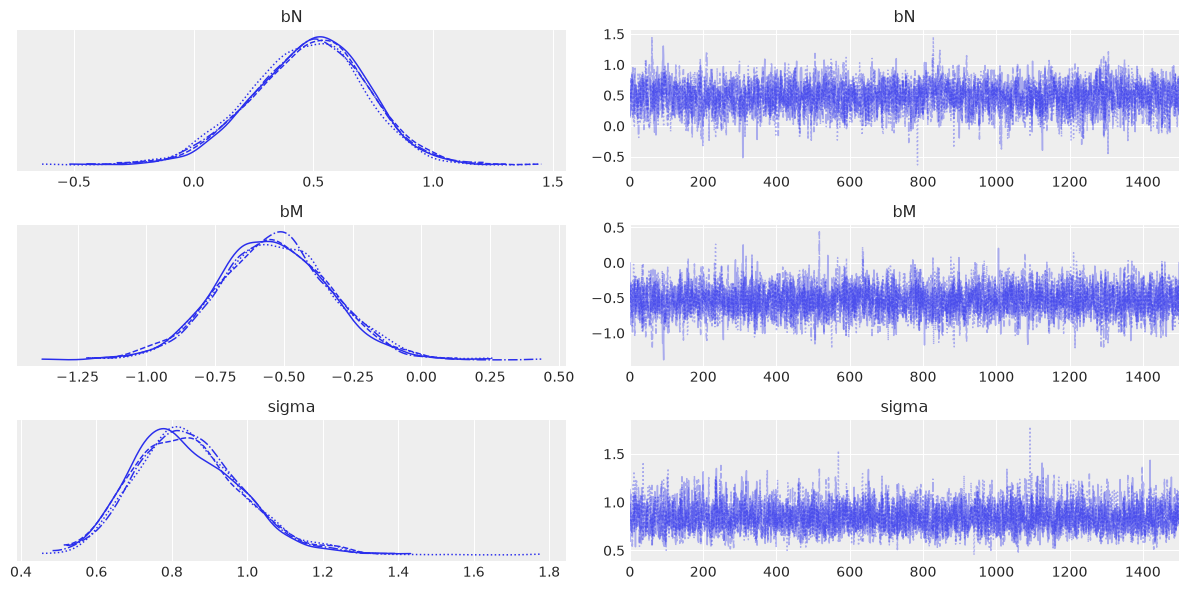

In [8]:
print(az.summary(idata, var_names=["a","bN","bM","sigma","nu","sigma_N"], hdi_prob=0.94)[["mean","sd","hdi_3%","hdi_97%","r_hat","ess_bulk","ess_tail"]])
print("\ndivergences:", int(idata.sample_stats.diverging.values.sum()), "| BFMI:", np.round(az.bfmi(idata),3))
az.plot_trace(idata, var_names=["bN","bM","sigma"]); plt.tight_layout(); plt.show()

## Stage 7 — Interpretation: the masked (suppression) effect

bN (neocortex) = +0.48 (94% HDI +0.01,+0.89)  -> bigger neocortex, MORE energetic milk
bM (log mass)  = -0.54 (94% HDI -0.93,-0.16)  -> bigger body, LESS energetic milk


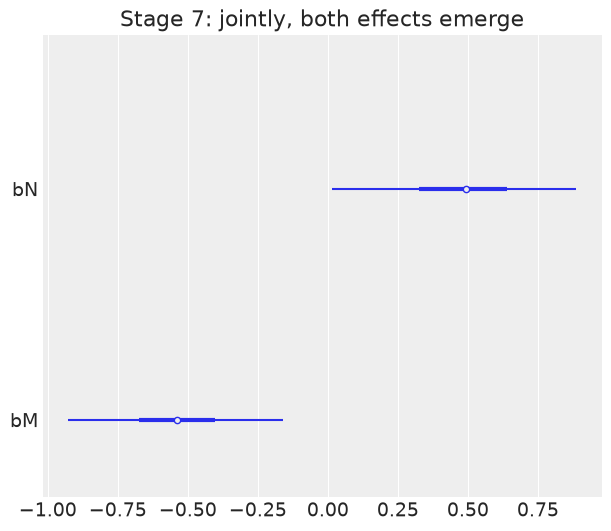

In [9]:
bN_m=idata.posterior["bN"].mean().item(); bM_m=idata.posterior["bM"].mean().item()
bN_h=az.hdi(idata,var_names=["bN"],hdi_prob=0.94)["bN"].values; bM_h=az.hdi(idata,var_names=["bM"],hdi_prob=0.94)["bM"].values
print(f"bN (neocortex) = {bN_m:+.2f} (94% HDI {bN_h[0]:+.2f},{bN_h[1]:+.2f})  -> bigger neocortex, MORE energetic milk")
print(f"bM (log mass)  = {bM_m:+.2f} (94% HDI {bM_h[0]:+.2f},{bM_h[1]:+.2f})  -> bigger body, LESS energetic milk")
az.plot_forest(idata, var_names=["bN","bM"], combined=True); plt.title("Stage 7: jointly, both effects emerge"); plt.show()

## Stage 8 — Posterior predictive check

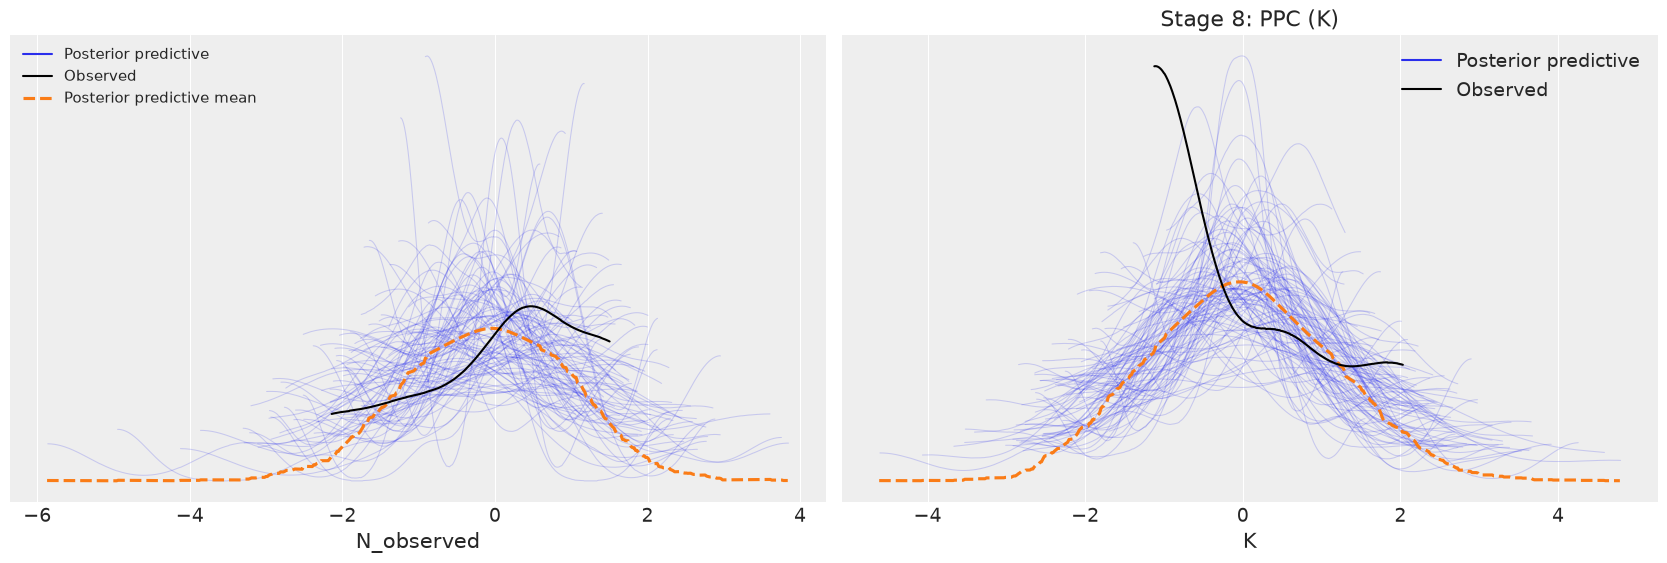

  mean: obs= -0.00  bayes-p=0.47
  sd  : obs=  0.98  bayes-p=0.73
  min : obs= -1.13  bayes-p=0.01
  max : obs=  2.03  bayes-p=0.63


In [10]:
az.plot_ppc(idata, num_pp_samples=100); plt.title("Stage 8: PPC (K)"); plt.show()
ppc = idata.posterior_predictive["K"].values.reshape(-1, K.size)
for name, fn in [("mean",np.mean),("sd",np.std),("min",np.min),("max",np.max)]:
    print(f"  {name:4s}: obs={fn(K):6.2f}  bayes-p={(fn(ppc,axis=1)>=fn(K)).mean():.2f}")

## Stage 9 — Model selection with PSIS-LOO (mass-only vs neocortex-only vs both)

In [11]:
def fit_one(use_N, use_M):
    with pm.Model() as mdl:
        a=pm.Normal("a",0,0.5); sigma=pm.Exponential("sigma",1); mu=a
        if use_N:
            nu=pm.Normal("nu",0,1); sN=pm.Exponential("sN",1)
            Ni=pm.Normal("N",nu,sN,observed=np.ma.masked_invalid(N)); bN=pm.Normal("bN",0,0.5); mu=mu+bN*Ni
        if use_M:
            bM=pm.Normal("bM",0,0.5); mu=mu+bM*M
        pm.Normal("K", mu, sigma, observed=K)
        return pm.sample(1500,tune=1500,chains=4,target_accept=0.95,random_seed=RANDOM_SEED,
                         progressbar=False, idata_kwargs={"log_likelihood":True})
idata_N = fit_one(True, False); idata_M = fit_one(False, True)
# the imputation models carry log-likelihood for both K and the imputed N; compare on the OUTCOME K only
cmp = az.compare({"both": idata, "mass_only": idata_M, "neocortex_only": idata_N}, var_name="K")
print(cmp[["rank","elpd_loo","elpd_diff","dse","weight"]])
S=idata.posterior.draw.size*idata.posterior.chain.size
print(f"\nmax Pareto k-hat (both): {az.loo(idata,pointwise=True,var_name='K').pareto_k.values.max():.2f} | threshold {min(1-1/np.log10(S),0.7):.2f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, sigma, nu, sN, N_unobserved, bN]


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 10 seconds.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, sigma, bM]


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 4 seconds.


                rank   elpd_loo  elpd_diff       dse        weight
both               0 -39.036935   0.000000  0.000000  1.000000e+00
mass_only          1 -41.502577   2.465642  1.123477  1.110223e-16
neocortex_only     2 -42.859467   3.822533  1.975836  0.000000e+00

max Pareto k-hat (both): 0.79 | threshold 0.70


## Stage 10 — Power-scaling prior sensitivity (bN, bM)

In [12]:
post=az.extract(idata); bNd=post["bN"].values; bMd=post["bM"].values
lp = st.norm.logpdf(bNd,0,0.5)+st.norm.logpdf(bMd,0,0.5)
print("alpha   E[bN]    E[bM]")
for al in [0.8,1.0,1.25]:
    w=np.exp((al-1)*lp); w/=w.sum(); print(f" {al:4.2f}   {np.sum(w*bNd):+.3f}  {np.sum(w*bMd):+.3f}")

alpha   E[bN]    E[bM]
 0.80   +0.516  -0.568
 1.00   +0.480  -0.537
 1.25   +0.442  -0.503


## SBC — Simulation-Based Calibration (capstone requirement)
Draw coefficients from the prior, simulate complete data, fit the complete-case model, rank `bN`.
Ranks ~uniform ⇒ calibrated (Talts et al. 2018).

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [a, bN, bM, sigma]


Sampling 2 chains for 400 tune and 300 draw iterations (800 + 600 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Multiprocess sampling (2 chains in 2 jobs)


NUTS: [a, bN, bM, sigma]


Sampling 2 chains for 400 tune and 300 draw iterations (800 + 600 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


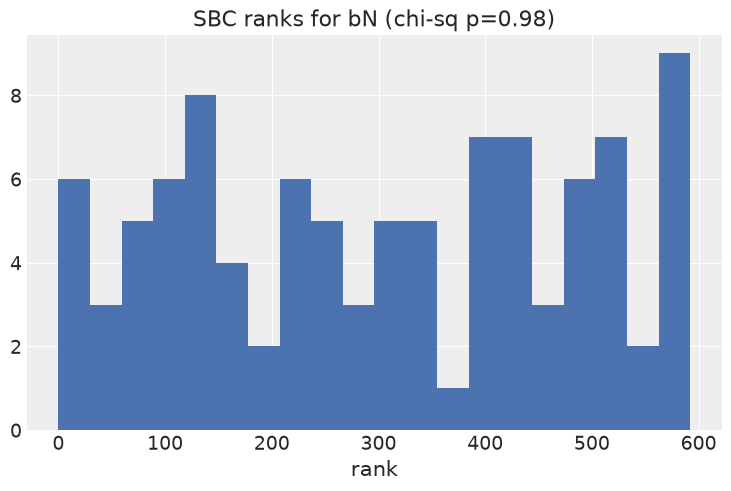

SBC: 100 sims | uniformity chi-square p=0.98 (>0.05 consistent with calibrated)


In [13]:
n_sim, ranks = 100, []
Msb = rng.normal(0,1,29)
for i in range(n_sim):
    a_t=rng.normal(0,0.5); bN_t=rng.normal(0,0.5); bM_t=rng.normal(0,0.5); s_t=rng.exponential(1)
    Nsb=rng.normal(0,1,29); Ksb=rng.normal(a_t+bN_t*Nsb+bM_t*Msb, s_t)
    with pm.Model() as ms:
        a=pm.Normal("a",0,0.5); bN=pm.Normal("bN",0,0.5); bM=pm.Normal("bM",0,0.5); sigma=pm.Exponential("sigma",1)
        pm.Normal("K", a+bN*Nsb+bM*Msb, sigma, observed=Ksb)
        ids=pm.sample(300,tune=400,chains=2,target_accept=0.9,random_seed=i,progressbar=False)
    d=ids.posterior["bN"].values.ravel(); ranks.append(int((d<bN_t).sum()))
ranks=np.array(ranks); L=len(d)
chi=st.chisquare(np.histogram(ranks,bins=10,range=(0,L))[0]).pvalue
plt.hist(ranks,bins=20,color="#4c72b0"); plt.title(f"SBC ranks for bN (chi-sq p={chi:.2f})"); plt.xlabel("rank"); plt.show()
print(f"SBC: {n_sim} sims | uniformity chi-square p={chi:.2f} (>0.05 consistent with calibrated)")

## Stage 11–12 — Synthesis, decision

**Expansion (Stage 11):** model the imputation with mass (`N_i ~ Normal(αN + βN·M_i, σN)`) so imputed
neocortex borrows strength from body size; or add `clade` as a varying intercept (ties back to Tier 3).

**Decision (Stage 12) — headline:** *across primates, milk becomes more energy-dense as relative
neocortex size rises and less dense as body mass rises — but **only a model with both predictors reveals
either**, because the two effects mask each other. Bayesian imputation lets all 29 species inform the fit
despite 12 missing neocortex values; LOO favours the two-predictor model; SBC confirms calibration.*

This capstone exercised every stage of the workflow loop — Stage 0 recovery, outcome-scale prior
predictive, model-aware diagnostics, PPC, LOO selection, power-scaling sensitivity, and SBC.

In [14]:
idata.to_netcdf("report/P20_idata.nc"); print("saved report/P20_idata.nc")

saved report/P20_idata.nc


## Exercises
1. Replace marginal imputation with mass-informed imputation `N ~ Normal(aN + bNM·M, sN)`. Do the imputed
   neocortex values and the coefficients change?
2. Add `clade` as a varying intercept and compare via LOO.
3. Drop the 12 incomplete rows (complete-case) and refit. Compare the coefficient uncertainty to the
   imputation model — what did imputation buy you?